# Samuel Choi, Henry Liang, Seongjune Kim, Zhengyi Yan, Seungbeom Yang, Daniil Siuziumov

# Table of Contents

1. [Task 1: Exploratory Data Analysis](#task1)
2. [Task 2: Classification Models](#task2)
3. [Task 3: Classification Quality Evaluation](#task3)

<a id="task1"></a>
## Task 1: Exploratory Data Analysis

In [ ]:
from pathlib import Path
import pandas as pd

# First check local notebook folders.
candidate_paths = [
    Path("."),              # train.csv and test.csv in same folder as notebook
    Path("./A3_data"),      # train.csv and test.csv inside A3_data folder
    Path("/content"),       # Colab root folder
    Path("/content/A3_data")
]

data_path = None

for path in candidate_paths:
    if (path / "train.csv").exists() and (path / "test.csv").exists():
        data_path = path
        break

# We used google drive for shared work
if data_path is None:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=True)

        drive_candidate_paths = [
            Path("/content/drive/Shareddrives/CS361_Assignment3/Assignment3"),
            Path("/content/drive/MyDrive/A3_data"),
            Path("/content/drive/MyDrive/CS361_Assignment3/Assignment3")
        ]

        for path in drive_candidate_paths:
            if (path / "train.csv").exists() and (path / "test.csv").exists():
                data_path = path
                break

    except Exception as e:
        print("Google Drive could not be mounted or checked:", e)

if data_path is None:
    raise FileNotFoundError(
        "Could not find train.csv and test.csv. "
        "Put them in the same folder as the notebook, inside ./A3_data, or in the expected Google Drive folder."
    )

train_df = pd.read_csv(data_path / "train.csv")
test_df = pd.read_csv(data_path / "test.csv")

print(f"Loaded data from: {data_path}")
display(train_df.head())
display(test_df.head())

Mounted at /content/drive
Loaded data from: /content/drive/Shareddrives/CS361_Assignment3/Assignment3


,Id,Article,Category
0,1976,lifestyle governs mobile choice faster better ...,tech
1,1797,french honour director parker british film dir...,entertainment
2,1866,fockers fuel festive film chart comedy meet fo...,entertainment
3,1153,housewives lift channel 4 ratings debut us tel...,entertainment
4,342,u2 desire number one u2 three prestigious gram...,entertainment


,Id,Article,Category
0,1821,johnny denise lose passport johnny vaughan den...,entertainment
1,522,bt offers free net phone calls bt offering cus...,tech
2,636,power people says hp digital revolution focuse...,tech
3,170,stars gear bafta ceremony film stars across gl...,entertainment
4,85,controversial film tops festival controversial...,entertainment


In [ ]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain columns:")
print(train_df.columns)

print("\nTest columns:")
print(test_df.columns)

display(train_df.head())
display(test_df.head())

Train shape: (428, 3)
Test shape: (106, 3)

Train columns:
Index(['Id', 'Article', 'Category'], dtype='object')

Test columns:
Index(['Id', 'Article', 'Category'], dtype='object')


,Id,Article,Category
0,1976,lifestyle governs mobile choice faster better ...,tech
1,1797,french honour director parker british film dir...,entertainment
2,1866,fockers fuel festive film chart comedy meet fo...,entertainment
3,1153,housewives lift channel 4 ratings debut us tel...,entertainment
4,342,u2 desire number one u2 three prestigious gram...,entertainment


,Id,Article,Category
0,1821,johnny denise lose passport johnny vaughan den...,entertainment
1,522,bt offers free net phone calls bt offering cus...,tech
2,636,power people says hp digital revolution focuse...,tech
3,170,stars gear bafta ceremony film stars across gl...,entertainment
4,85,controversial film tops festival controversial...,entertainment


In [ ]:
print("Missing values in train:")
print(train_df.isnull().sum())

print("\nMissing values in test:")
print(test_df.isnull().sum())

print("\nTraining class distribution:")
print(train_df["Category"].value_counts())

print("\nTesting class distribution:")
print(test_df["Category"].value_counts())

Missing values in train:
Id          0
Article     0
Category    0
dtype: int64

Missing values in test:
Id          0
Article     0
Category    0
dtype: int64

Training class distribution:
Category
tech             216
entertainment    212
Name: count, dtype: int64

Testing class distribution:
Category
entertainment    61
tech             45
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

X_train_count = count_vectorizer.fit_transform(train_df["Article"])
X_test_count = count_vectorizer.transform(test_df["Article"])

feature_names = count_vectorizer.get_feature_names_out()

print("Number of training articles:", X_train_count.shape[0])
print("Number of testing articles:", X_test_count.shape[0])
print("Number of extracted features:", X_train_count.shape[1])

Number of training articles: 428
Number of testing articles: 106
Number of extracted features: 13518


In [ ]:
import pandas as pd

example_rows = []

for idx in range(5):
    row_vector = X_train_count[idx].toarray().flatten()
    non_zero_indices = row_vector.nonzero()[0]

    extracted_features = {
        feature_names[i]: row_vector[i]
        for i in non_zero_indices[:20]
    }

    example_rows.append({
        "Id": train_df.loc[idx, "Id"],
        "Category": train_df.loc[idx, "Category"],
        "Article Preview": train_df.loc[idx, "Article"][:150] + "...",
        "Extracted Features": extracted_features
    })

example_df = pd.DataFrame(example_rows)
display(example_df)

,Id,Category,Article Preview,Extracted Features
0,1976,tech,lifestyle governs mobile choice faster better ...,"{'000': 1, '14': 2, '2003': 2, '25': 1, '29': ..."
1,1797,entertainment,french honour director parker british film dir...,"{'2003': 1, 'alan': 3, 'also': 1, 'artist': 1,..."
2,1866,entertainment,fockers fuel festive film chart comedy meet fo...,"{'12': 3, '121': 1, '165': 1, '19': 1, '1m': 2..."
3,1153,entertainment,housewives lift channel 4 ratings debut us tel...,"{'11': 1, '12': 1, '20': 1, '2002': 1, '2004':..."
4,342,entertainment,u2 desire number one u2 three prestigious gram...,"{'10': 1, '12': 1, '125': 1, '17': 1, '1978': ..."


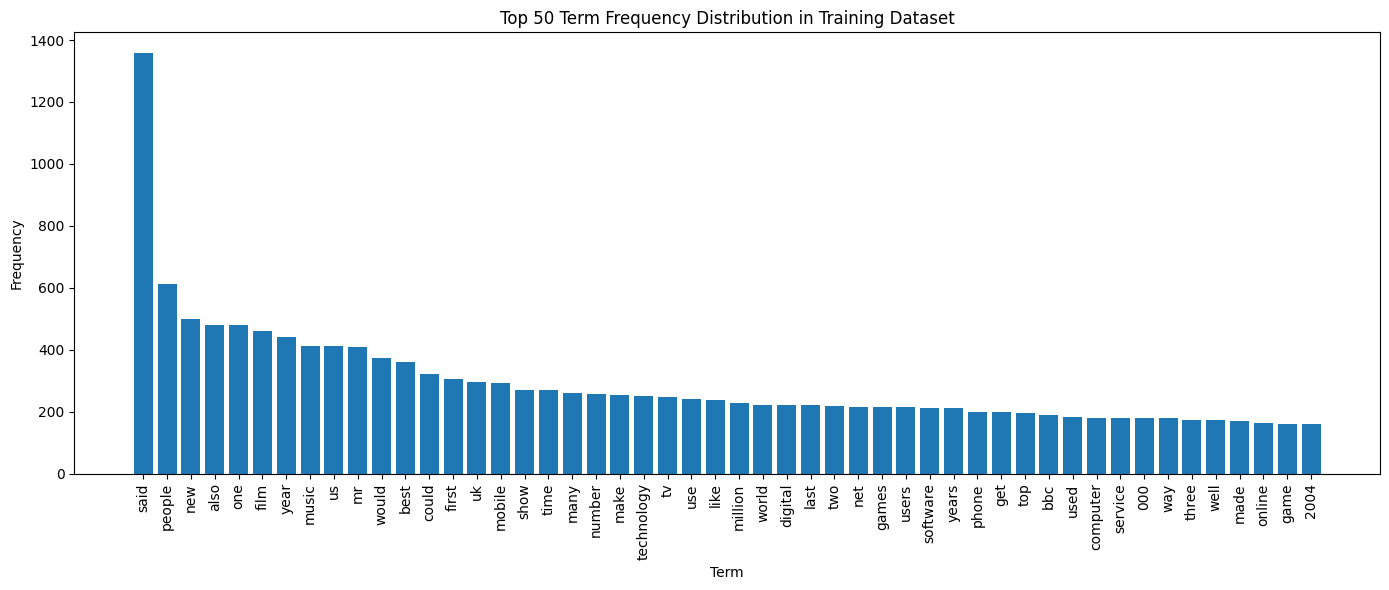

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

term_frequencies = np.asarray(X_train_count.sum(axis=0)).flatten()

term_freq_df = pd.DataFrame({
    "term": feature_names,
    "frequency": term_frequencies
})

top_50_terms = term_freq_df.sort_values(by="frequency", ascending=False).head(50)

plt.figure(figsize=(14, 6))
plt.bar(top_50_terms["term"], top_50_terms["frequency"])
plt.xticks(rotation=90)
plt.xlabel("Term")
plt.ylabel("Frequency")
plt.title("Top 50 Term Frequency Distribution in Training Dataset")
plt.tight_layout()
plt.show()

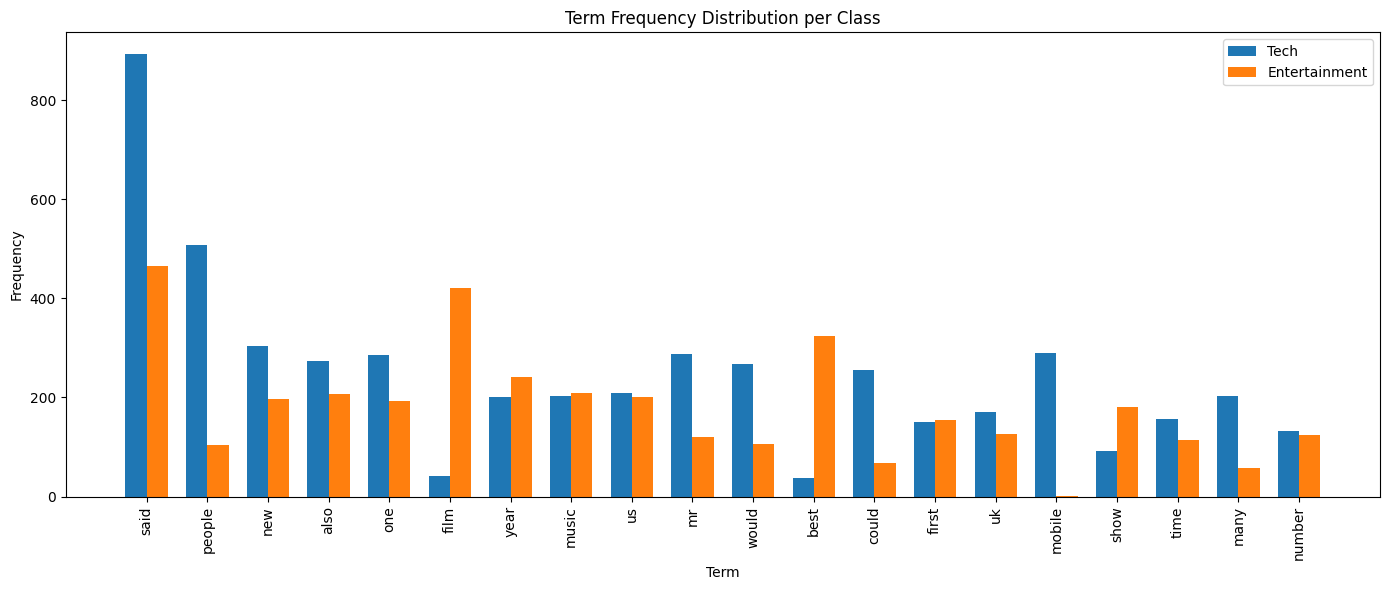

In [ ]:
tech_articles = train_df[train_df["Category"] == "tech"]["Article"]
entertainment_articles = train_df[train_df["Category"] == "entertainment"]["Article"]

X_tech = count_vectorizer.transform(tech_articles)
X_entertainment = count_vectorizer.transform(entertainment_articles)

tech_freq = np.asarray(X_tech.sum(axis=0)).flatten()
entertainment_freq = np.asarray(X_entertainment.sum(axis=0)).flatten()

class_term_freq_df = pd.DataFrame({
    "term": feature_names,
    "tech_frequency": tech_freq,
    "entertainment_frequency": entertainment_freq
})

top_20_overall_terms = term_freq_df.sort_values(
    by="frequency", ascending=False
).head(20)["term"]

combined_class_freq = class_term_freq_df[
    class_term_freq_df["term"].isin(top_20_overall_terms)
].copy()

combined_class_freq = combined_class_freq.set_index("term").loc[top_20_overall_terms]

x = np.arange(len(combined_class_freq.index))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, combined_class_freq["tech_frequency"], width, label="Tech")
plt.bar(x + width/2, combined_class_freq["entertainment_frequency"], width, label="Entertainment")

plt.xticks(x, combined_class_freq.index, rotation=90)
plt.xlabel("Term")
plt.ylabel("Frequency")
plt.title("Term Frequency Distribution per Class")
plt.legend()
plt.tight_layout()
plt.show()

,Train,Test
Category,,
entertainment,212,61
tech,216,45


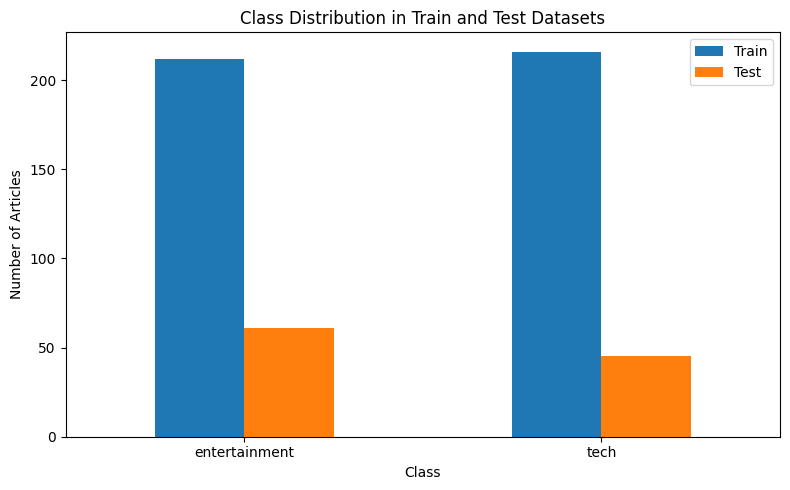

In [ ]:
train_class_counts = train_df["Category"].value_counts()
test_class_counts = test_df["Category"].value_counts()

class_distribution_df = pd.DataFrame({
    "Train": train_class_counts,
    "Test": test_class_counts
}).fillna(0)

display(class_distribution_df)

class_distribution_df.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Class")
plt.ylabel("Number of Articles")
plt.title("Class Distribution in Train and Test Datasets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In Task 1, we loaded the BBC news training and testing datasets and inspected their structure. Each article was represented as a numerical feature vector using CountVectorizer, where each feature corresponds to a word from the training vocabulary and each value represents the frequency of that word in the article. The number of articles and extracted features were reported for both datasets. Five example articles were displayed with a sample of their extracted non-zero features. The top-50 term frequency plot showed the most common words in the training dataset, while the class-specific frequency plot compared common terms between tech and entertainment articles. Finally, the class distribution plot was used to check whether the train and test datasets were balanced across the two categories.


<a id="task2"></a>
## Task 2: Classification Models

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score

y_train = train_df["Category"]
y_test = test_df["Category"]

# From the scikit-learn, MultinomialNB is the most suitable here because our features are word counts.
# alpha=1.0 applies for the Laplace smoothing.
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_count, y_train)

nb_pred = nb_model.predict(X_test_count)

accuracy = nb_model.score(X_test_count, y_test)
print("Naive Bayes Accuracy:", round(accuracy, 3))

print("Naive Bayes macro F1:", round(f1_score(y_test, nb_pred, average="macro"), 3))

Naive Bayes Accuracy: 0.972
Naive Bayes macro F1: 0.971


In [ ]:
# Top 20 most predictive words for each class

# nb_model.feature_log_prob_ gives log probabilities, so we convert them back
# into normal probabilities using np.exp()
prob_table = pd.DataFrame(
    np.exp(nb_model.feature_log_prob_),
    nb_model.classes_,
    feature_names
)

top20_words_with_probs = pd.DataFrame()

# For each class, sort the words by probability and take the top 20
for class_name in nb_model.classes_:
    top20_words = (prob_table.loc[class_name].sort_values(ascending=False).head(20))
    top20_words_with_probs[f"{class_name}_Word"] = top20_words.index
    top20_words_with_probs[f"{class_name}_Prob"] = top20_words.values

display(top20_words_with_probs)

,entertainment_Word,entertainment_Prob,tech_Word,tech_Prob
0,said,0.008412,said,0.011797
1,film,0.007600,people,0.006711
2,best,0.005867,new,0.004029
3,year,0.004369,mobile,0.003844
4,music,0.003809,mr,0.003818
5,also,0.003737,one,0.003791
6,us,0.003647,also,0.003620
7,new,0.003556,would,0.003540
8,one,0.003502,could,0.003382
9,show,0.003267,technology,0.003276


In [ ]:
# Top 20 most discriminative words between the two classes

# P(word | tech) / P(word | entertainment)
ratio = prob_table.loc["tech"] / prob_table.loc["entertainment"]

#sort the value to get the top 20
top20_ratio = ratio.sort_values(ascending=False).head(20)
print(top20_ratio)

# Put the result into a dataframe
discriminative_words = pd.DataFrame()

discriminative_words["Word"] = top20_ratio.index
discriminative_words["P(word|tech)"] = prob_table.loc["tech", top20_ratio.index].values
discriminative_words["P(word|entertainment)"] = prob_table.loc["entertainment", top20_ratio.index].values
discriminative_words["Ratio tech / entertainment"] = top20_ratio.values

display(discriminative_words)

users           157.338895
software        156.607086
microsoft       113.430366
mobile          106.478182
broadband        94.403337
virus            90.012484
firms            83.426205
pc               79.767161
spam             62.203749
phones           53.056139
gadget           52.690235
net              52.446298
consumer         50.494808
mobiles          49.762999
machines         49.031191
windows          49.031191
gadgets          49.031191
technologies     47.567573
systems          46.835764
pcs              46.103955
dtype: float64


,Word,P(word|tech),P(word|entertainment),Ratio tech / entertainment
0,users,0.002840,0.000018,157.338895
1,software,0.002827,0.000018,156.607086
2,microsoft,0.002048,0.000018,113.430366
3,mobile,0.003844,0.000036,106.478182
4,broadband,0.001704,0.000018,94.403337
5,virus,0.001625,0.000018,90.012484
6,firms,0.001506,0.000018,83.426205
7,pc,0.001440,0.000018,79.767161
8,spam,0.001123,0.000018,62.203749
9,phones,0.001916,0.000036,53.056139


### Task2 (a): NB
For Naive Bayes I found the top predictive words by sorting the probability of each word from the given class. These words tell us which terms are most common in tech articles and entertainment articles. To find the discriminative words I used the ratio P(word|tech) / P(word|entertainment). I think this list is more helpful for telling tech and entertainment articles. This is because it shows words that are strongly linked to tech compared to entertainment. It does not just show words that're common in both. The discriminative list helps to highlight the differences between the two classes. It shows which words are more likely to appear in tech articles v.s. entertainment articles.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

y_train = train_df["Category"]
y_test = test_df["Category"]

knn_model = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_model.fit(X_train_count, y_train)

knn_pred = knn_model.predict(X_test_count)

print("KNN Accuracy:", round(knn_model.score(X_test_count, y_test), 3))
print("KNN macro F1:", round(f1_score(y_test, knn_pred, average="macro"), 3))

KNN Accuracy: 0.755
KNN macro F1: 0.709


In [ ]:
# Reduce the word-count features into 2D for plotting
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.inspection import DecisionBoundaryDisplay

# Convert labels into numbers for plotting
label_encoder = LabelEncoder()
y_train_num = label_encoder.fit_transform(y_train)
y_test_num = label_encoder.transform(y_test)

# Reduce the word-count features into 2D
svd = TruncatedSVD(n_components=2, random_state=42)

X_train_2d = svd.fit_transform(X_train_count)
X_test_2d = svd.transform(X_test_count)

# Put 2D data into a dataframe so the plot labels are clearer
X_train_2d_df = pd.DataFrame(
    X_train_2d,
    columns=["SVD component 1", "SVD component 2"]
)

X_test_2d_df = pd.DataFrame(
    X_test_2d,
    columns=["SVD component 1", "SVD component 2"]
)

# Choose kNN hyperparameters
k_value = 5
distance_metric = "euclidean"

# Build the kNN model
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=k_value,
        metric=distance_metric
    ))
])

# Train Model
knn_model.fit(X_train_2d_df, y_train_num)

knn_pred = knn_model.predict(X_test_2d_df)

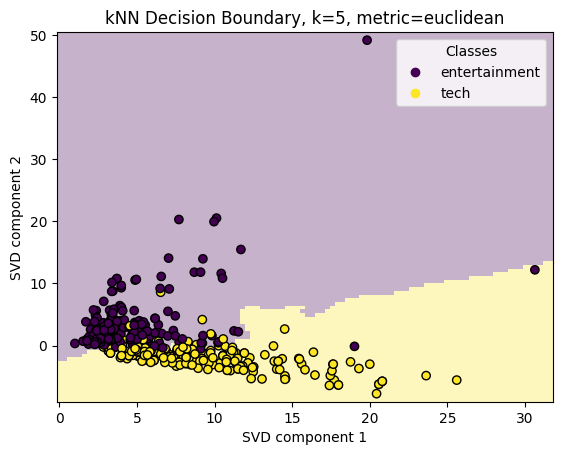

In [ ]:
# Plot the kNN decision boundary

disp = DecisionBoundaryDisplay.from_estimator(
    knn_model,
    X_train_2d_df,
    response_method="predict",
    plot_method="pcolormesh",
    alpha=0.3,
    xlabel="SVD component 1",
    ylabel="SVD component 2",
    shading="auto"
)

scatter = plt.scatter(
    X_train_2d_df["SVD component 1"],
    X_train_2d_df["SVD component 2"],
    c=y_train_num,
    edgecolors="k"
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=list(label_encoder.classes_),
    title="Classes"
)

plt.title(f"kNN Decision Boundary, k={k_value}, metric={distance_metric}")
plt.show()

### Task2 (b): kNN
For the kNN classifier I picked the k = 5 and I used Euclidean distance. The k value of 5 means the kNN classifier looks at the nearest five points in the training set to figure out whether the new point should form. I chose this because it is not as sensitive to noise as k = 1.

The k hyperparameter changes how the kNN classifier makes decisions. When k is small the border between groups is really jagged because the kNN classifier focuses more to each point in the training set. When k is bigger the border is smoother because the kNN classifier considers more points however if k is too big the kNN classifier might underfit.

The way the kNN classifier measures distance also changes how it makes decisions because it decides what the kNN classifier means by "nearest". I used Euclidean distance with the kNN classifier, which measures the straight  line between points in the 2D space.


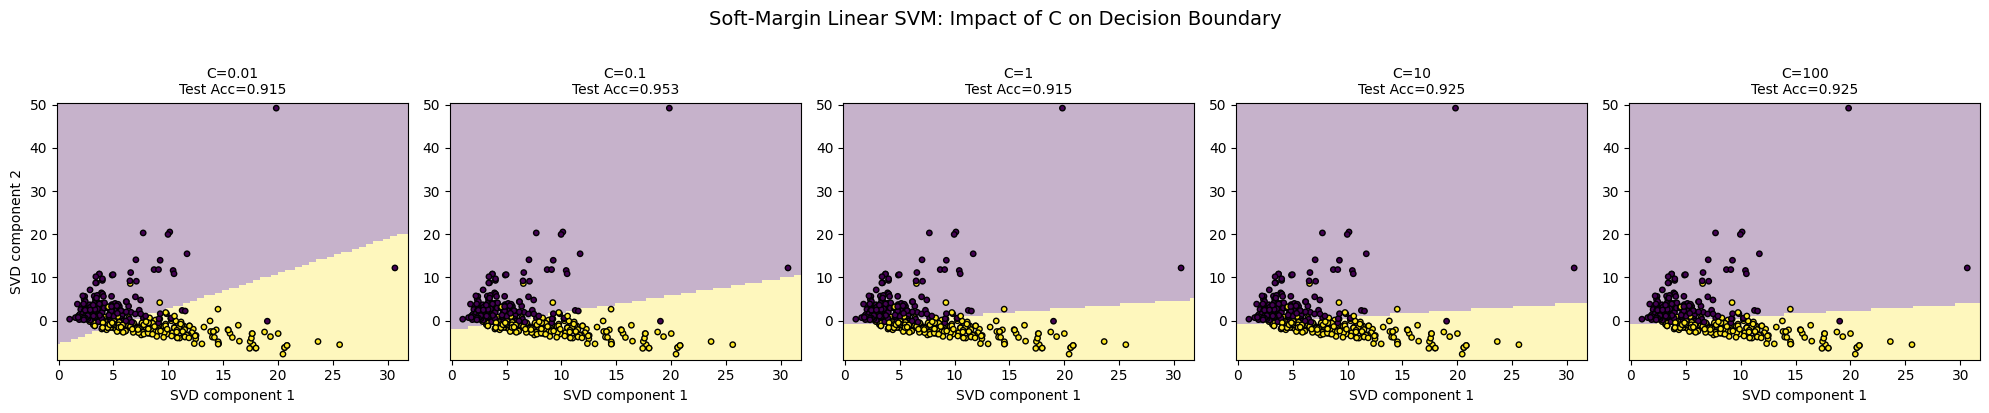

In [ ]:
# ============================================
# Q2 (c) SVM
# ============================================

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 2D reduction (same TruncatedSVD as kNN section)
label_encoder = LabelEncoder()
y_train_num = label_encoder.fit_transform(y_train)
y_test_num = label_encoder.transform(y_test)

svd = TruncatedSVD(n_components=2, random_state=42)
X_train_2d = svd.fit_transform(X_train_count)
X_test_2d = svd.transform(X_test_count)

X_train_2d_df = pd.DataFrame(X_train_2d, columns=["SVD component 1", "SVD component 2"])
X_test_2d_df = pd.DataFrame(X_test_2d, columns=["SVD component 1", "SVD component 2"])

# Soft-margin linear SVM with varying C
C_values = [0.01, 0.1, 1, 10, 100]

fig, axes = plt.subplots(1, len(C_values), figsize=(20, 4))
fig.suptitle("Soft-Margin Linear SVM: Impact of C on Decision Boundary", fontsize=14, y=1.02)

for idx, C_val in enumerate(C_values):
    svm_linear = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=C_val, random_state=42))
    ])
    svm_linear.fit(X_train_2d_df, y_train_num)

    ax = axes[idx]
    DecisionBoundaryDisplay.from_estimator(
        svm_linear, X_train_2d_df,
        response_method="predict", plot_method="pcolormesh",
        alpha=0.3, ax=ax, shading="auto"
    )
    scatter = ax.scatter(
        X_train_2d_df["SVD component 1"], X_train_2d_df["SVD component 2"],
        c=y_train_num, edgecolors="k", s=15
    )
    acc = svm_linear.score(X_test_2d_df, y_test_num)
    ax.set_title(f"C={C_val}\nTest Acc={acc:.3f}", fontsize=10)
    ax.set_xlabel("SVD component 1")
    ax.set_ylabel("SVD component 2" if idx == 0 else "")

plt.tight_layout()
plt.show()

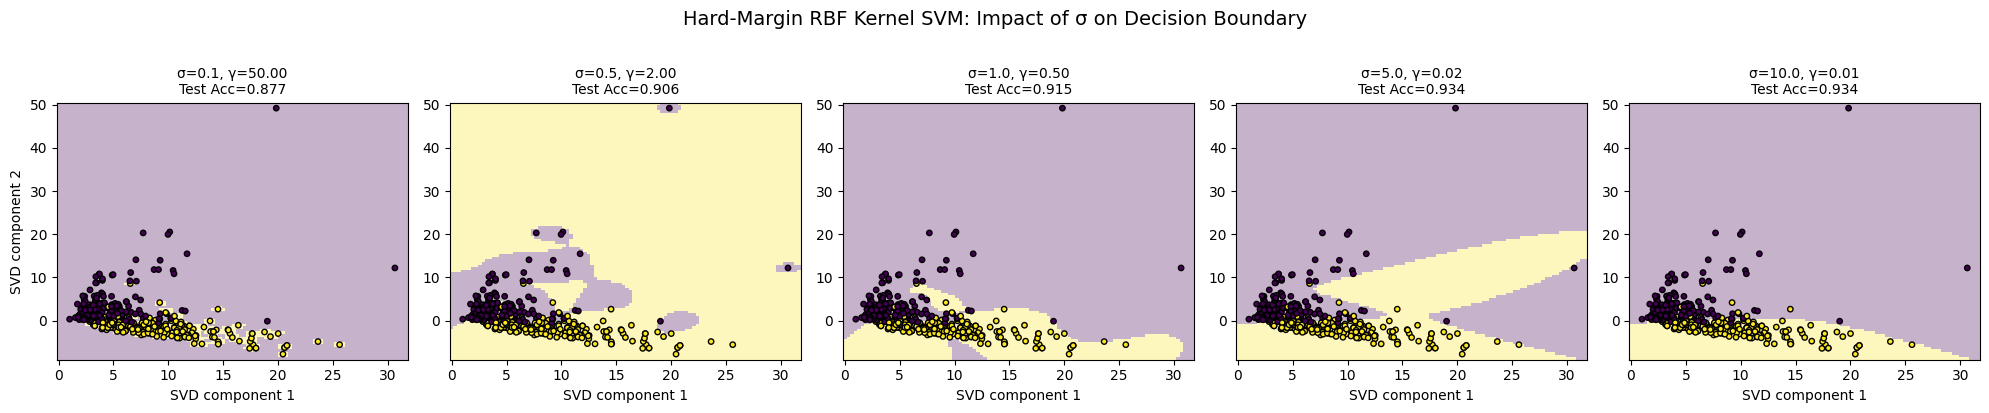

In [ ]:
# Hard-margin RBF SVM: large C approximates hard margin, sigma varies
sigma_values = [0.1, 0.5, 1.0, 5.0, 10.0]
gamma_values = [1.0 / (2 * s**2) for s in sigma_values]
C_hard = 1e6

fig, axes = plt.subplots(1, len(sigma_values), figsize=(20, 4))
fig.suptitle("Hard-Margin RBF Kernel SVM: Impact of σ on Decision Boundary", fontsize=14, y=1.02)

for idx, (sigma, gamma) in enumerate(zip(sigma_values, gamma_values)):
    svm_rbf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=C_hard, gamma=gamma, random_state=42))
    ])
    svm_rbf.fit(X_train_2d_df, y_train_num)

    ax = axes[idx]
    DecisionBoundaryDisplay.from_estimator(
        svm_rbf, X_train_2d_df,
        response_method="predict", plot_method="pcolormesh",
        alpha=0.3, ax=ax, shading="auto"
    )
    ax.scatter(
        X_train_2d_df["SVD component 1"], X_train_2d_df["SVD component 2"],
        c=y_train_num, edgecolors="k", s=15
    )
    acc = svm_rbf.score(X_test_2d_df, y_test_num)
    ax.set_title(f"σ={sigma}, γ={gamma:.2f}\nTest Acc={acc:.3f}", fontsize=10)
    ax.set_xlabel("SVD component 1")
    ax.set_ylabel("SVD component 2" if idx == 0 else "")

plt.tight_layout()
plt.show()

### Task2 (c): SVM
We used TruncatedSVD to project the high-dimensional features into 2D, consistent with the kNN section, to enable decision boundary visualization.
<br>
<br>
**Soft-margin linear SVM (impact of C):** <br>
The parameter C controls the trade-off between maximizing the margin and minimizing misclassification. When C is small (e.g., 0.01), the model allows more misclassifications in exchange for a wider margin, resulting in a simpler, smoother decision boundary. As C increases (e.g., 10, 100), the model penalizes misclassifications more heavily, fitting the training data more tightly and producing a boundary that follows the data more closely. From the plots, C=0.1 achieved the best test accuracy (0.953), suggesting that a moderate amount of margin tolerance generalizes better than strict fitting.
<br>
<br>
**Hard-margin RBF kernel SVM (impact of σ):** <br>
The kernel width σ controls how far the influence of a single training point reaches. A small σ (e.g., 0.1) means each point has very local influence, leading to a highly complex, overfitting decision boundary that closely wraps around individual points (high γ = 50). A large σ (e.g., 10.0) means each point influences a wide area, producing a smoother, more linear-like boundary (low γ = 0.01). From the plots, σ=5.0 and σ=10.0 achieved the best test accuracy (0.934), indicating that broader kernels generalize better for this dataset.

Hidden units:  2 | Final training loss: 0.0015 | Test macro F1: 0.971
Hidden units:  5 | Final training loss: 0.0026 | Test macro F1: 0.962
Hidden units: 20 | Final training loss: 0.0009 | Test macro F1: 0.962
Hidden units: 40 | Final training loss: 0.0011 | Test macro F1: 0.943



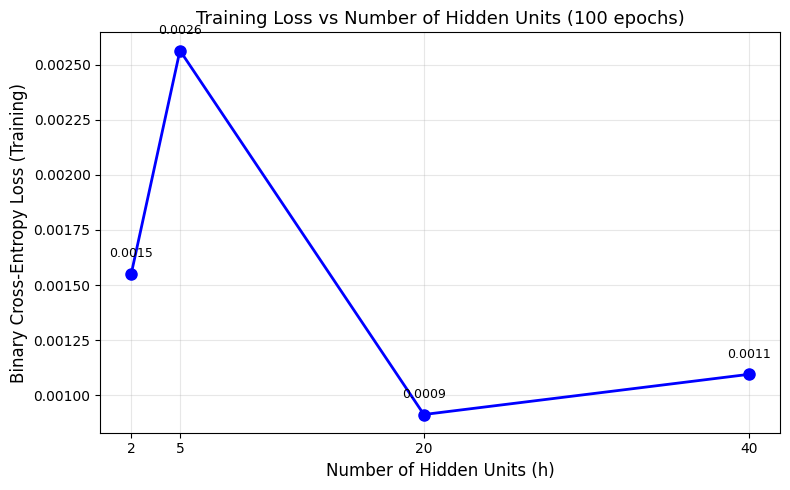

In [ ]:
# ============================================
# Q2 (d) ANN
# ============================================

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Scale full-dimensional data for ANN
scaler_ann = StandardScaler(with_mean=False)  # with_mean=False for sparse matrix
X_train_scaled = scaler_ann.fit_transform(X_train_count)
X_test_scaled = scaler_ann.transform(X_test_count)

hidden_units_list = [2, 5, 20, 40]
losses = []

for h in hidden_units_list:
    mlp = MLPClassifier(
        hidden_layer_sizes=(h,),
        activation='relu',
        solver='sgd',
        learning_rate='constant',
        learning_rate_init=0.01,
        max_iter=100,
        random_state=42,
        batch_size=min(200, X_train_scaled.shape[0]),
        verbose=False
    )
    mlp.fit(X_train_scaled, y_train)

    final_loss = mlp.loss_curve_[-1]
    losses.append(final_loss)

    pred_ann = mlp.predict(X_test_scaled)
    f1 = f1_score(y_test, pred_ann, average='macro')
    print(f"Hidden units: {h:2d} | Final training loss: {final_loss:.4f} | Test macro F1: {f1:.3f}")

print() # means nothing, just for space between the text and graph

# Plot
plt.figure(figsize=(8, 5))
plt.plot(hidden_units_list, losses, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Number of Hidden Units (h)", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss (Training)", fontsize=12)
plt.title("Training Loss vs Number of Hidden Units (100 epochs)", fontsize=13)
plt.xticks(hidden_units_list)
plt.grid(True, alpha=0.3)

for h, loss in zip(hidden_units_list, losses):
    plt.annotate(f"{loss:.4f}", (h, loss), textcoords="offset points", xytext=(0, 12), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Task2 (d): ANN
We trained a single hidden layer neural network (MLPClassifier) with learning rate 0.01 and 100 epochs, varying the number of hidden units h ∈ {2, 5, 20, 40}.
<br>
<br>
**Effect of hidden units on training loss:**
<br>
Generally, increasing the number of hidden units reduces the training loss because a larger network has more parameters and greater capacity to fit the training data. From h=5 to h=20, we observe a clear drop in loss, as the network gains enough capacity to model the decision boundary effectively.
<br>
<br>
However, the loss does not decrease monotonically — h=2 achieves a lower loss than h=5, which may be due to the simpler model converging more stably with SGD in 100 epochs. At h=40, the loss slightly increases compared to h=20, suggesting that with more parameters the optimization landscape becomes harder to navigate in only 100 epochs, and the model may need more training time to fully converge. Overall, h=20 achieved the lowest training loss (0.0009), while h=2 achieved the best test F1 (0.971), indicating that more hidden units do not necessarily improve generalization.

<a id="task3"></a>
## Task 3: Classification Quality Evaluation

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro


Best hyperparameter settings:


,Model,Hyperparameter,Value,Mean CV F1,Std CV F1
41,ANN,learning rate,0.1,0.9673,0.0136
0,Naive Bayes,alpha,0.01,0.9860,0.0114
21,SVM,kernel and C,"linear, C=0.01",0.9790,0.0136
18,kNN,k and metric,"k=5, metric=cosine",0.9556,0.0135


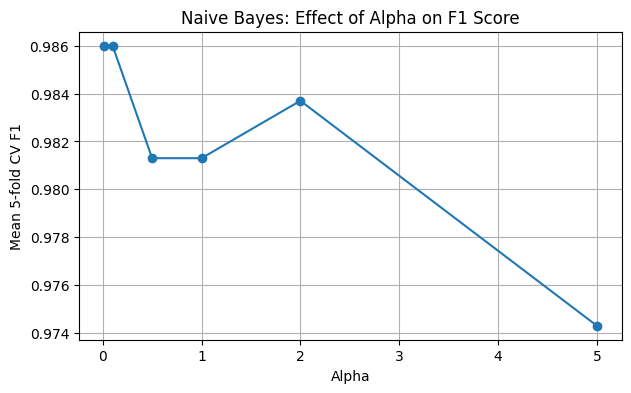

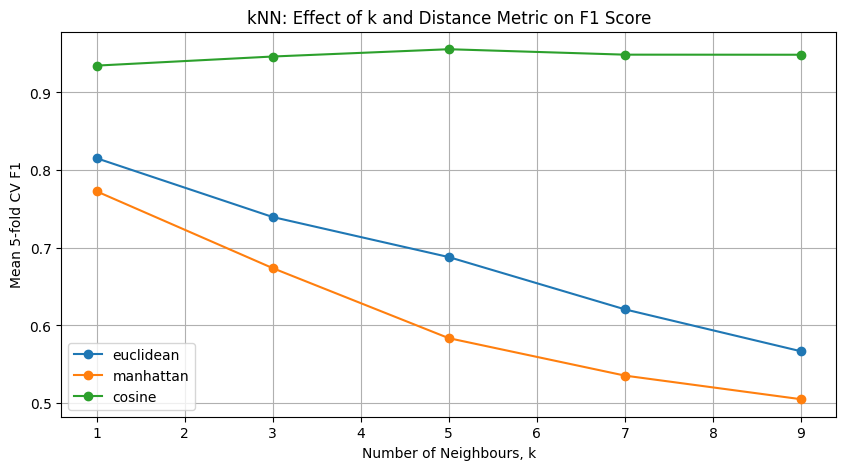

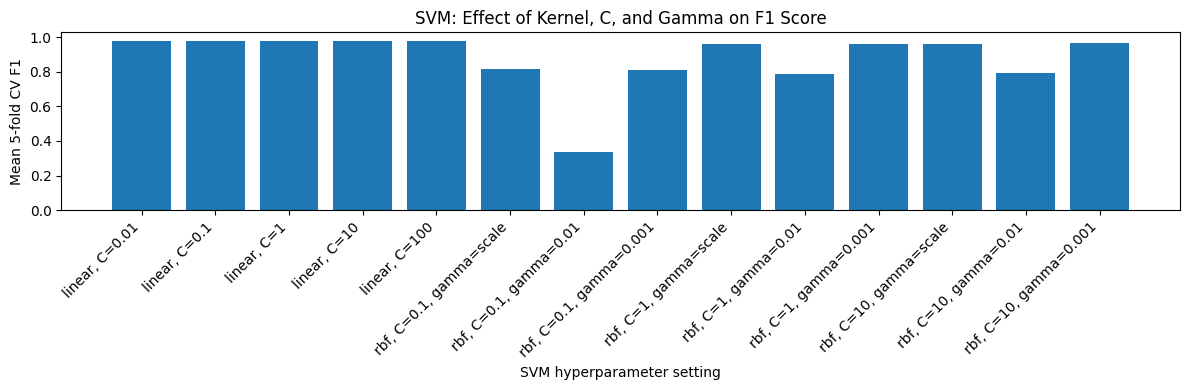

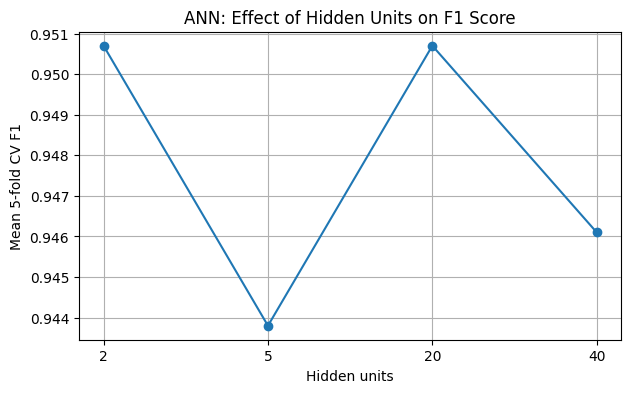

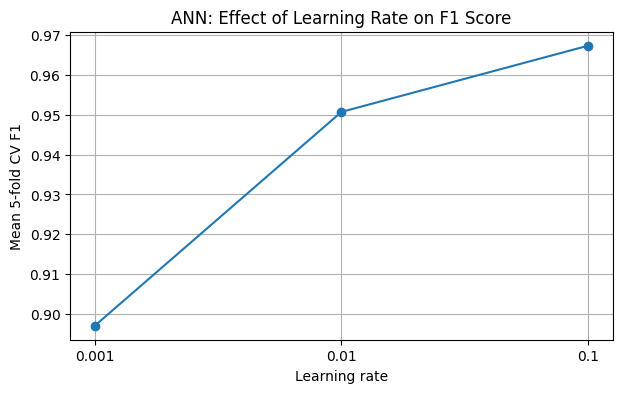

In [ ]:
# Setting up cross validation
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# 5-fold validation using StratifiedKFold to keep classes balanced
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

# Testing hyperparameter for Naive Bayes (alpha)
alpha_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]

for alpha in alpha_values:
    nb_model = MultinomialNB(alpha=alpha)

    scores = cross_val_score(
        nb_model,
        X_train_count,
        y_train,
        cv=cv,
        scoring="f1_macro"
    )

    results.append({
        "Model": "Naive Bayes",
        "Hyperparameter": "alpha",
        "Value": alpha,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

# Testing hyperparameter for KNN (n_neighbours, metric)
k_values = [1, 3, 5, 7, 9]
metrics = ["euclidean", "manhattan", "cosine"]

for metric in metrics:
    for k in k_values:
        knn_model = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )

        scores = cross_val_score(
            knn_model,
            X_train_count,
            y_train,
            cv=cv,
            scoring="f1_macro"
        )

        results.append({
            "Model": "kNN",
            "Hyperparameter": "k and metric",
            "Value": f"k={k}, metric={metric}",
            "Mean CV F1": scores.mean(),
            "Std CV F1": scores.std()
        })

# Testing hyperparameters for SVM: kernel, C, and gamma

# Linear SVM: test different C values
linear_C_values = [0.01, 0.1, 1, 10, 100]

for C in linear_C_values:
    svm_model = LinearSVC(
        C=C,
        random_state=42,
        max_iter=5000
    )

    scores = cross_val_score(
        svm_model,
        X_train_count,
        y_train,
        cv=cv,
        scoring="f1_macro"
    )

    results.append({
        "Model": "SVM",
        "Hyperparameter": "kernel and C",
        "Value": f"linear, C={C}",
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })


# RBF SVM: test different C and gamma values
rbf_C_values = [0.1, 1, 10]
gamma_values = ["scale", 0.01, 0.001]

for C in rbf_C_values:
    for gamma in gamma_values:
        svm_model = SVC(
            kernel="rbf",
            C=C,
            gamma=gamma,
            random_state=42
        )

        scores = cross_val_score(
            svm_model,
            X_train_count,
            y_train,
            cv=cv,
            scoring="f1_macro"
        )

        results.append({
            "Model": "SVM",
            "Hyperparameter": "kernel, C and gamma",
            "Value": f"rbf, C={C}, gamma={gamma}",
            "Mean CV F1": scores.mean(),
            "Std CV F1": scores.std()
        })

# Testing hyperparameter for ANN
hidden_units_list = [2, 5, 20, 40]

for h in hidden_units_list:
    ann_model = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(h,),
            activation="relu",
            solver="sgd",
            learning_rate_init=0.01,
            max_iter=100,
            random_state=42,
            batch_size=200
        ))
    ])

    scores = cross_val_score(
        ann_model,
        X_train_count,
        y_train,
        cv=cv,
        scoring="f1_macro"
    )

    results.append({
        "Model": "ANN",
        "Hyperparameter": "hidden units",
        "Value": h,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

# Learning rate test
learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:
    ann_model = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(20,),
            activation="relu",
            solver="sgd",
            learning_rate_init=lr,
            max_iter=100,
            random_state=42,
            batch_size=200
        ))
    ])

    scores = cross_val_score(
        ann_model,
        X_train_count,
        y_train,
        cv=cv,
        scoring="f1_macro"
    )

    results.append({
        "Model": "ANN",
        "Hyperparameter": "learning rate",
        "Value": lr,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })


# Creating results dataframe
results_df = pd.DataFrame(results)

results_df["Mean CV F1"] = results_df["Mean CV F1"].round(4)
results_df["Std CV F1"] = results_df["Std CV F1"].round(4)

# Full cross-validation results are stored in results_df.
# We display only the best settings below to keep the notebook concise.

#display(results_df)

# Find the best setting for each model
best_results = results_df.loc[
    results_df.groupby("Model")["Mean CV F1"].idxmax()
]
print()
print("Best hyperparameter settings:")
display(best_results)

# Visualising the results

# Naive Bayes
nb_results = results_df[results_df["Model"] == "Naive Bayes"]

plt.figure(figsize=(7, 4))
plt.plot(nb_results["Value"], nb_results["Mean CV F1"], marker="o")
plt.xlabel("Alpha")
plt.ylabel("Mean 5-fold CV F1")
plt.title("Naive Bayes: Effect of Alpha on F1 Score")
plt.grid(True)
plt.show()

# KNN
knn_results = results_df[results_df["Model"] == "kNN"]

plt.figure(figsize=(10, 5))

for metric in metrics:
    subset = knn_results[knn_results["Value"].str.contains(f"metric={metric}")]

    plt.plot(
        k_values,
        subset["Mean CV F1"],
        marker="o",
        label=metric
    )

plt.xlabel("Number of Neighbours, k")
plt.ylabel("Mean 5-fold CV F1")
plt.title("kNN: Effect of k and Distance Metric on F1 Score")
plt.legend()
plt.grid(True)
plt.show()

# SVM
svm_results = results_df[results_df["Model"] == "SVM"]

plt.figure(figsize=(12, 4))
plt.bar(
    svm_results["Value"].astype(str),
    svm_results["Mean CV F1"]
)

plt.xlabel("SVM hyperparameter setting")
plt.ylabel("Mean 5-fold CV F1")
plt.title("SVM: Effect of Kernel, C, and Gamma on F1 Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ANN
ann_hidden_results = results_df[
    (results_df["Model"] == "ANN") &
    (results_df["Hyperparameter"] == "hidden units")
]

plt.figure(figsize=(7, 4))
plt.plot(
    ann_hidden_results["Value"].astype(str),
    ann_hidden_results["Mean CV F1"],
    marker="o"
)

plt.xlabel("Hidden units")
plt.ylabel("Mean 5-fold CV F1")
plt.title("ANN: Effect of Hidden Units on F1 Score")
plt.grid(True)
plt.show()

# ANN learning rate
ann_lr_results = results_df[
    (results_df["Model"] == "ANN") &
    (results_df["Hyperparameter"] == "learning rate")
]

plt.figure(figsize=(7, 4))
plt.plot(
    ann_lr_results["Value"].astype(str),
    ann_lr_results["Mean CV F1"],
    marker="o"
)

plt.xlabel("Learning rate")
plt.ylabel("Mean 5-fold CV F1")
plt.title("ANN: Effect of Learning Rate on F1 Score")
plt.grid(True)
plt.show()

### Task 3 (a): Impact of Hyperparameters on Cross-Validation Performance

We evaluated selected hyperparameters for all four classifiers using 5-fold cross-validation and macro F1 on the training set.

For Naive Bayes, we tested the smoothing parameter alpha. The model performed strongly across all tested values. The best cross-validation performance was achieved when alpha = 0.01, with a mean F1 score of 0.9860. However, alpha = 0.1 produced the same rounded mean F1 score, so both settings performed very similarly. Larger values, especially alpha = 5.0, reduced the mean F1 score to 0.9743. This suggests that a small amount of smoothing is useful, but too much smoothing can weaken the effect of class-specific words.

For kNN, we tested the number of neighbours k and the distance metric. The results show that the distance metric had a large effect on performance. Cosine distance clearly outperformed Euclidean and Manhattan distance, with the best result achieved using k = 5 and metric = cosine, giving a mean F1 score of 0.9556. Euclidean and Manhattan distance performed much worse as k increased. This is reasonable for text classification because articles are represented as high-dimensional word-count vectors, and cosine distance compares the direction of vectors rather than their raw magnitude.

For SVM, we tested both linear and RBF kernels. For the linear SVM, we varied the regularisation parameter C. For the RBF SVM, we varied both C and gamma. The linear SVM was very stable across all tested C values, with each setting achieving the same rounded mean F1 score of 0.9790. The best RBF result was achieved using C = 10 and gamma = 0.001, with a mean F1 score of 0.9649. Overall, the linear kernel performed better than the tested RBF settings, suggesting that the word-count features were already well separated by a linear decision boundary.

For ANN, we tested the number of hidden units and the initial learning rate. The hidden-units experiment used learning_rate_init = 0.01, while the learning-rate experiment fixed the hidden layer size at 20 units. The hidden-units results were relatively similar, with the best rounded mean F1 score of 0.9507 achieved using either 2 or 20 hidden units. The learning-rate experiment showed a stronger effect: learning_rate_init = 0.001 gave a lower mean F1 score of 0.8971, while learning_rate_init = 0.1 achieved the best ANN result of 0.9673. This suggests that the ANN was more sensitive to learning rate than to the number of hidden units in this experiment.

### Task 3 (b):


In [ ]:
from sklearn.metrics import f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

# -----------------------------
# Best hyperparameter settings
# -----------------------------

# Naive Bayes
nb_best = MultinomialNB(alpha=0.01)

# kNN
knn_best = KNeighborsClassifier(
    n_neighbors=5,
    metric="cosine"
)

# SVM
svm_best = LinearSVC(
    C=0.01,
    random_state=42,
    max_iter=5000
)

# ANN
ann_best = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(20,),
        activation="relu",
        solver="sgd",
        learning_rate_init=0.1,
        max_iter=100,
        random_state=42,
        batch_size=200
    ))
])

# Store models
models = {
    "Naive Bayes": nb_best,
    "kNN": knn_best,
    "SVM": svm_best,
    "ANN": ann_best
}

results = []

# Train and evaluate
for name, model in models.items():

    model.fit(X_train_count, y_train)

    y_pred = model.predict(X_test_count)

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    results.append([name, round(f1, 4)])

# Create results table
test_results_df = pd.DataFrame(
    results,
    columns=["Model", "Test F1 Score"]
)

# Sort best to worst
test_results_df = test_results_df.sort_values(
    by="Test F1 Score",
    ascending=False
)

display(test_results_df)

,Model,Test F1 Score
3,ANN,1.0000
2,SVM,1.0000
0,Naive Bayes,0.9808
1,kNN,0.9523


The four classifiers were evaluated on the test dataset using their best hyperparameter settings selected from 5-fold cross-validation in Task 3(a). The performance was measured using the macro F1 score.

 The results are as follows:

SVM: 1.0000
ANN: 1.0000
Naive Bayes: 0.9808
kNN: 0.9523

Both SVM and ANN achieved perfect F1 scores (1.0000) on the test dataset, indicating near-perfect separation between the two classes (tech and entertainment). This suggests that the feature representation (bag-of-words / count vectorisation) is highly linearly separable for this classification task.

The Naive Bayes classifier also performed strongly (0.9808), which is expected for text classification tasks where word frequencies are highly informative and the conditional independence assumption works reasonably well despite being a simplification.

The kNN classifier achieved the lowest performance (0.9523) among the four models. This is likely due to the high dimensionality and sparsity of text data, which reduces the effectiveness of distance-based methods even when cosine similarity is used.

Overall, SVM and ANN performed best, showing that both linear decision boundaries and learned nonlinear representations are highly effective for this dataset. Naive Bayes remains a strong and efficient baseline, while kNN is less suitable for high-dimensional sparse text representations.

### Task 3 (c):

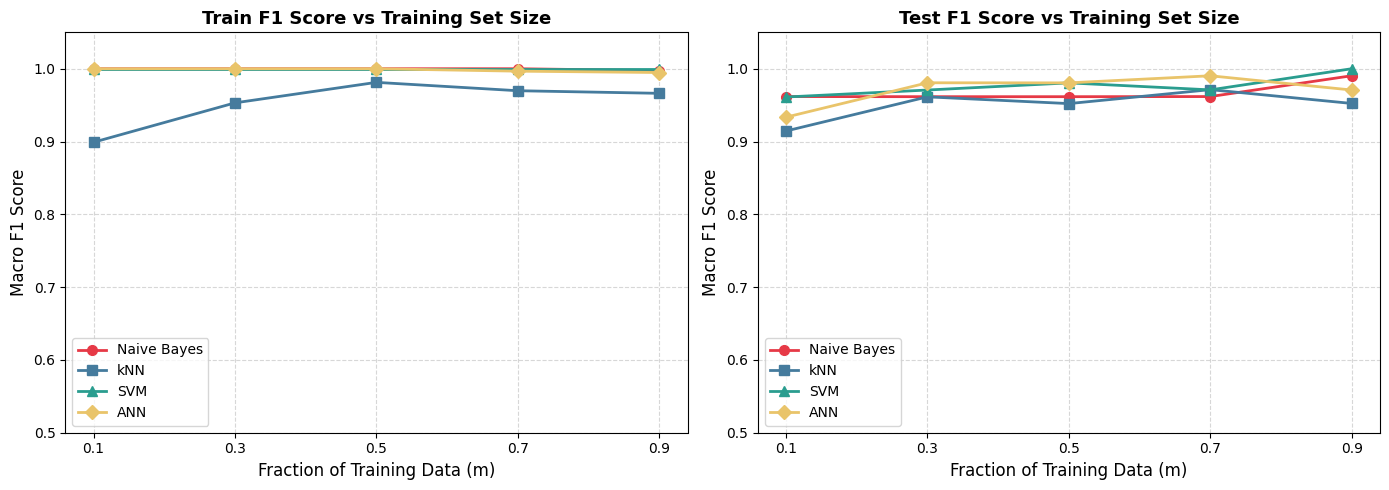

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

X_train = X_train_count
X_test = X_test_count

classifiers = {
    'Naive Bayes': MultinomialNB(alpha=0.01),
    'kNN':         KNeighborsClassifier(n_neighbors=5, metric='cosine'),
    'SVM':         SVC(kernel='linear', C=0.01),
    'ANN':         MLPClassifier(hidden_layer_sizes=(20,), learning_rate_init=0.1,
                                  max_iter=100, random_state=42),
}

m_values = [0.1, 0.3, 0.5, 0.7, 0.9]
N = X_train.shape[0]

train_f1 = {name: [] for name in classifiers}
test_f1  = {name: [] for name in classifiers}

for m in m_values:
    n_samples = int(m * N)
    X_sub = X_train[:n_samples]
    y_sub = y_train[:n_samples]

    for name, clf in classifiers.items():
        clf.fit(X_sub, y_sub)
        train_f1[name].append(f1_score(y_sub,  clf.predict(X_sub),  average='macro'))
        test_f1[name].append( f1_score(y_test, clf.predict(X_test), average='macro'))

colors    = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
markers   = ['o', 's', '^', 'D']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, title in zip(
    axes,
    [train_f1, test_f1],
    ['Train F1 Score vs Training Set Size', 'Test F1 Score vs Training Set Size']
):
    for (name, vals), color, marker in zip(scores.items(), colors, markers):
        ax.plot(m_values, vals, marker=marker, label=name,
                color=color, linewidth=2, markersize=7)
    ax.set_xlabel('Fraction of Training Data (m)', fontsize=12)
    ax.set_ylabel('Macro F1 Score', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(m_values)
    ax.set_ylim(0.5, 1.05)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('task3c_learning_curves.png', dpi=150)
plt.show()

As m increases, test F1 generally improves across all four classifiers, reflecting that more training data reduces variance and improves generalisation.
Train F1 remains near 1.0 for NB, SVM, and ANN even at small m, indicating these models fit small subsets well. kNN shows the clearest improvement in both train and test F1 as m grows as it relies on having nearby neighbors, requiring it to need more data. By m=0.9, all classifiers all classifiers converge to a similarly high test F1 score, meaning that the dataset is relatively easy to classify.